## 🛠 Exercises

Just implement some of the interesting functions from Unit 06

# OLD code:

## Import the right modules for tensorflow.keras

In [1]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf
print(tf.__version__) # find the version number (should be 2.x+)
print(tf.config.list_physical_devices('GPU'))

version_fn = getattr(tf.keras, "version", None)
if version_fn and version_fn().startswith("3."):
    import tf_keras as keras
else:
    keras = tf.keras

2.20.0-dev20250526
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Load my own dataset: porous templates

### 1. Import and inspect data

In [2]:
import os

# Set images directory:
dir_images = "AAO_images/"

# Walk through the images directory and list number of files:
for dirpath, dirnames, filenames in os.walk(dir_images):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 2 directories and 0 images in 'AAO_images/'.
There are 4 directories and 0 images in 'AAO_images/test'.
There are 0 directories and 88 images in 'AAO_images/test/r4a7_PmenorIgual30'.
There are 0 directories and 65 images in 'AAO_images/test/r12a15_Pmayor40'.
There are 0 directories and 39 images in 'AAO_images/test/r4a7_Pmayor30'.
There are 0 directories and 65 images in 'AAO_images/test/r12a15_PmenorIgual40'.
There are 4 directories and 0 images in 'AAO_images/train'.
There are 0 directories and 354 images in 'AAO_images/train/r4a7_PmenorIgual30'.
There are 0 directories and 256 images in 'AAO_images/train/r12a15_Pmayor40'.
There are 0 directories and 159 images in 'AAO_images/train/r4a7_Pmayor30'.
There are 0 directories and 254 images in 'AAO_images/train/r12a15_PmenorIgual40'.


In [3]:
# Get the class names (programmatically, this is much more helpful with a longer list of classes)
import pathlib
import numpy as np

data_dir = pathlib.Path(dir_images+'train/') # turn our training path into a Python path
class_names = np.array(sorted([item.name for item in data_dir.glob('*')])) # created a list of class_names from the subdirectories
print(class_names)

['r12a15_Pmayor40' 'r12a15_PmenorIgual40' 'r4a7_Pmayor30'
 'r4a7_PmenorIgual30']


In [4]:
# View an image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

def view_random_image(target_dir, target_class):
  # Setup target directory (we'll view images from here)
  target_folder = target_dir+target_class

  # Get a random image path
  random_image = random.sample(os.listdir(target_folder), 1)

  # Read in the image and plot it using matplotlib
  img = mpimg.imread(target_folder + "/" + random_image[0])
  plt.imshow(img,cmap='gray')
  plt.title(target_class)
  plt.axis("off");

  print(f"Image shape: {img.shape}") # show the shape of the image

  return img

Image shape: (256, 256)


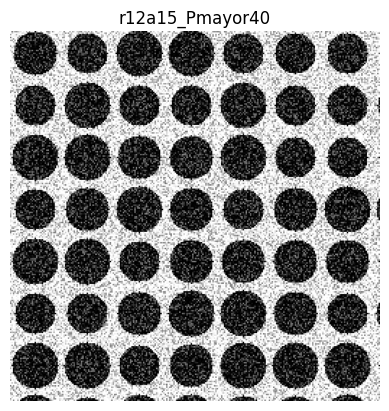

In [5]:
# View a random image from the training dataset
img = view_random_image(target_dir=dir_images+'train/',
                        target_class="r12a15_Pmayor40")

### 2. Preprocess the data

In [ ]:
# Setup the train and test directories
train_dir = dir_images+"train/"
test_dir = dir_images+"test/"

# Create data inputs
IMG_SIZE = (256, 256) # define image size
train_data = tf.keras.preprocessing.image_dataset_from_directory(directory=train_dir,
                                                                 image_size=IMG_SIZE,
                                                                 color_mode='rgb', # Convert to 3 channels
                                                                 label_mode="categorical", # what type are the labels?
                                                                 batch_size=32) # batch_size is 32 by default, this is generally a good number
test_data = tf.keras.preprocessing.image_dataset_from_directory(directory=test_dir,
                                                                image_size=IMG_SIZE,
                                                                color_mode='rgb', # Convert to 3 channels
                                                                label_mode="categorical")

### 3. Build a transfer learning model

In [ ]:
INIT_EPOCHS = 10
IMG_SHAPE = (256, 256, 3)
N_CLASSES = len(class_names)

# 1. Create base model with tf.keras.applications
base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(include_top=False)

# 2. Freeze the base model (so the pre-learned patterns remain)
base_model.trainable = False

# 3. Create inputs into the base model
inputs = tf.keras.layers.Input(shape=IMG_SHAPE, name="input_layer")

# 4. Pass the inputs to the base_model (note: using tf.keras.applications, EfficientNetV2 inputs don't have to be normalized)
x = base_model(inputs)
# Check data shape after passing it to base_model
print(f"Shape after base_model: {x.shape}")

# 5. Average pool the outputs of the base model (aggregate all the most important information, reduce number of computations)
x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)
print(f"After GlobalAveragePooling2D(): {x.shape}")

# 6. Create the output activation layer
outputs = tf.keras.layers.Dense(N_CLASSES, activation="softmax", name="output_layer")(x)

# 7. Combine the inputs with the outputs into a model
model_0 = tf.keras.Model(inputs, outputs)

# 8. Compile the model
model_0.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

# 9. Fit the model (we use less steps for validation so it's faster)
history_0 = model_0.fit(train_data,
                        epochs=INIT_EPOCHS,
                        # steps_per_epoch=len(train_data),
                        validation_data=test_data,
                        # Go through less of the validation data so epochs are faster (we want faster experiments!)
                        validation_steps=int(0.5 * len(test_data)),
                        )

In [ ]:
model_0.summary()

In [ ]:
from helper_functions import plot_acc_curves

# Check out our model's training curves
plot_acc_curves(history_0)

### 4. Adding data augmentation right into the model

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# NEW: Newer versions of TensorFlow (2.10+) can use the tensorflow.keras.layers API directly for data augmentation
data_augmentation = keras.Sequential([
  layers.RandomFlip(),
  layers.RandomZoom(0.2),
], name ="data_augmentation")

In [ ]:
# View a random image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random
target_class = random.choice(train_data.class_names) # choose a random class
target_dir = "AAO_images/train/" + target_class # create the target directory
random_image = random.choice(os.listdir(target_dir)) # choose a random image from target directory
random_image_path = target_dir + "/" + random_image # create the choosen random image path
img = mpimg.imread(random_image_path) # read in the chosen target image
plt.imshow(img) # plot the target image
plt.title(f"Original random image from class: {target_class}")
plt.axis(False); # turn off the axes

# Augment the image
augmented_img = data_augmentation(tf.expand_dims(img, axis=0)) # data augmentation model requires shape (None, height, width, 3)
plt.figure()
plt.imshow(tf.squeeze(augmented_img)/255.) # requires normalization after augmentation
plt.title(f"Augmented random image from class: {target_class}")
plt.axis(False);

### 5. Build a model with augmented data:

In [ ]:
# Setup input shape and base model, freezing the base model layers
base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(include_top=False)
base_model.trainable = False

data_augmentation = keras.Sequential([
  layers.RandomFlip(),
  layers.RandomZoom(0.2),
], name ="data_augmentation")

# Create input layer
inputs = layers.Input(shape=IMG_SHAPE, name="input_layer")

# Add in data augmentation Sequential model as a layer
x = data_augmentation(inputs)

# Give base_model inputs (after augmentation) and don't train it
x = base_model(x, training=False)

# Pool output features of base model
x = layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)

# Put a dense layer on as the output
outputs = layers.Dense(N_CLASSES, activation="softmax", name="output_layer")(x)

# Make a model with inputs and outputs
model_1 = keras.Model(inputs, outputs)

# Compile the model
model_1.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

# Fit the model
history_1 = model_1.fit(train_data,
                        epochs=INIT_EPOCHS,
                        # steps_per_epoch=len(train_data_1_percent),
                        validation_data=test_data,
                        validation_steps=int(0.5* len(test_data)), # validate for less steps
                        )

In [ ]:
# Check out our model's training curves
plot_acc_curves(history_1)

### 6. Fine-tune an existing model:

In [ ]:
def create_base_model(input_shape: tuple[int, int, int] = IMG_SHAPE,
                      output_shape: int = N_CLASSES,
                      learning_rate: float = 0.001,
                      training: bool = False) -> tf.keras.Model:
    """
    Create a model based on EfficientNetV2B0 with built-in data augmentation.

    Parameters:
    - input_shape (tuple): Expected shape of input images. Default is (224, 224, 3).
    - output_shape (int): Number of classes for the output layer. Default is 10.
    - learning_rate (float): Learning rate for the Adam optimizer. Default is 0.001.
    - training (bool): Whether the base model is trainable. Default is False.

    Returns:
    - tf.keras.Model: The compiled model with specified input and output settings.
    """
    # Create base model
    base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(include_top=False)
    base_model.trainable = training

    # Setup model input and outputs with data augmentation built-in
    inputs = layers.Input(shape=input_shape, name="input_layer")
    x = data_augmentation(inputs)
    x = base_model(x, training=False)  # pass augmented images to base model but keep it in inference mode
    x = layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)
    outputs = layers.Dense(units=output_shape, activation="softmax", name="output_layer")(x)
    model = tf.keras.Model(inputs, outputs)

    # Compile model
    model.compile(loss="categorical_crossentropy",
                  optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  metrics=["accuracy"])

    return model

# Create an instance of model_2 with our new function
model_2 = create_base_model()

In [ ]:
# # Setup checkpoint path
checkpoint_path = "AAO_model_checkpoints_weights/checkpoint.weights.h5" # note: remember saving directly to Colab is temporary

# # Create a ModelCheckpoint callback that saves the model's weights only
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                                         save_weights_only=True, # set to False to save the entire model
                                                         save_best_only=True, # save only the best model weights instead of a model every epoch
                                                         save_freq="epoch", # save every epoch
                                                         verbose=1)

In [ ]:
model_2.layers

In [ ]:
# Access the base_model layers of model_2
model_2_base_model = model_2.layers[2]
model_2_base_model.name

In [ ]:
# How many layers are trainable in our model_2_base_model?
print(len(model_2_base_model.trainable_variables)) # layer at index 2 is the EfficientNetV2B0 layer (the base model)

In [ ]:
# Fit the model saving checkpoints every epoch
history_2_frozen = model_2.fit(train_data,
                               epochs=INIT_EPOCHS,
                               validation_data=test_data,
                               validation_steps=int(0.5 * len(test_data)), # do less steps per validation (quicker)
                               callbacks=[checkpoint_callback])

In [ ]:
# Evaluate on the test data
results_2_frozen = model_2.evaluate(test_data)
results_2_frozen

In [ ]:
# # Load in saved model weights and evaluate model
model_2.load_weights(checkpoint_path)
loaded_weights_model_results = model_2.evaluate(test_data)
loaded_weights_model_results

In [ ]:
# Make all the layers in model_2_base_model trainable
model_2_base_model.trainable = True

# Freeze all layers except for the last 10
for layer in model_2_base_model.layers[:-10]:
  layer.trainable = False

# Recompile the whole model (always recompile after any adjustments to a model)
model_2.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # lr is 10x lower than before for fine-tuning
                metrics=["accuracy"])

# How many layers are trainable in our model_2_base_model?
print(len(model_2_base_model.trainable_variables)) # layer at index 2 is the EfficientNetV2B0 layer (the base model)

In [ ]:
print(len(model_2.trainable_variables))

In [ ]:
# Fine tune for another 5 epochs
FINE_EPOCHS = 10
fine_tune_epochs = INIT_EPOCHS + FINE_EPOCHS

# Refit the model (same as model_2 except with more trainable layers)
history_2_fine = model_2.fit(train_data,
                             epochs=fine_tune_epochs,
                             validation_data=test_data,
                             initial_epoch=history_2_frozen.epoch[-1], # start from previous last epoch
                             validation_steps=int(0.5 * len(test_data))) 

In [ ]:
# Evaluate the model on the test data
results_2_fine = model_2.evaluate(test_data)

In [ ]:
def compare_historys(original_history, new_history, initial_epochs=INIT_EPOCHS):
    """
    Compares two model history objects.
    """
    # Get original history measurements
    acc = original_history.history["accuracy"]
    loss = original_history.history["loss"]

    print(len(acc))

    val_acc = original_history.history["val_accuracy"]
    val_loss = original_history.history["val_loss"]

    # Combine original history with new history
    total_acc = acc + new_history.history["accuracy"]
    total_loss = loss + new_history.history["loss"]

    total_val_acc = val_acc + new_history.history["val_accuracy"]
    total_val_loss = val_loss + new_history.history["val_loss"]

    print(len(total_acc))
    print(total_acc)

    # Make plots
    plt.figure(figsize=(8, 8))
    plt.subplot(2, 1, 1)
    plt.plot(total_acc, label='Training Accuracy')
    plt.plot(total_val_acc, label='Validation Accuracy')
    plt.plot([initial_epochs-1, initial_epochs-1],
              plt.ylim(), label='Start Fine Tuning') # reshift plot around epochs
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(2, 1, 2)
    plt.plot(total_loss, label='Training Loss')
    plt.plot(total_val_loss, label='Validation Loss')
    plt.plot([initial_epochs-1, initial_epochs-1],
              plt.ylim(), label='Start Fine Tuning') # reshift plot around epochs
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.xlabel('epoch')
    plt.show()

In [ ]:
compare_historys(original_history=history_2_frozen,
                 new_history=history_2_fine,
                 initial_epochs=INIT_EPOCHS)

# NEW code:

In [ ]:
model_2.evaluate(test_data)

In [47]:
# Make predictions with model
pred_probs = model_2.predict(test_data, verbose=1) # set verbosity to see how long it will take 

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


In [49]:
# How do they look?
pred_probs[:10]

array([[2.6302978e-03, 1.4618893e-02, 6.3339889e-02, 9.1941094e-01],
       [5.2931480e-04, 9.9944645e-01, 1.9292862e-05, 4.8798279e-06],
       [3.7808266e-01, 6.2142599e-01, 3.4817189e-04, 1.4318409e-04],
       [3.5281992e-03, 9.9642271e-01, 3.4494311e-05, 1.4606186e-05],
       [1.2672136e-03, 9.9870515e-01, 2.2029000e-05, 5.6173385e-06],
       [1.3759693e-03, 2.3311528e-03, 9.4675016e-01, 4.9542662e-02],
       [5.6105026e-04, 3.3698234e-04, 9.9828523e-01, 8.1678072e-04],
       [9.9550593e-01, 3.7765813e-03, 3.8946667e-04, 3.2805064e-04],
       [8.0590085e-05, 9.1653172e-04, 1.0595842e-03, 9.9794322e-01],
       [1.8105931e-03, 2.2905739e-03, 1.0172322e-02, 9.8572659e-01]],
      dtype=float32)

In [ ]:
#### NOTE: THERE IS A PROBLEM WHEN LOADING THE TRUE CLASSES, BECAUSE THEY ARE WRONGLY LABELED.
### THE MODEL PERFORMS WELL, THE PROBLEM ARE THE TRUE CLASSES, WHICH ARE NOT TRUE...

In [50]:
# Get the class predicitons of each label
pred_classes = pred_probs.argmax(axis=1)

# How do they look?
pred_classes[:10]

array([3, 1, 1, 1, 1, 2, 2, 0, 3, 3])

In [54]:
# Note: This might take a minute or so due to unravelling 790 batches
y_labels = []
for images, labels in test_data.unbatch(): # unbatch the test data and get images and labels
    y_labels.append(labels.numpy().argmax()) # append the index which has the largest value (labels are one-hot)
y_labels[:10] # check what they look like (unshuffled)

[np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(2),
 np.int64(3),
 np.int64(1),
 np.int64(2),
 np.int64(2),
 np.int64(0),
 np.int64(0)]

In [56]:
# Get accuracy score by comparing predicted classes to ground truth labels
from sklearn.metrics import accuracy_score
sklearn_accuracy = accuracy_score(y_labels, pred_classes)
sklearn_accuracy

0.29571984435797666

In [57]:
# Note: The following confusion matrix code is a remix of Scikit-Learn's 
# plot_confusion_matrix function - https://scikit-learn.org/stable/modules/generated/sklearn.metrics.plot_confusion_matrix.html
import itertools
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Our function needs a different name to sklearn's plot_confusion_matrix
def make_confusion_matrix(y_true, y_pred, classes=None, figsize=(10, 10), text_size=15, norm=False, savefig=False): 
  """Makes a labelled confusion matrix comparing predictions and ground truth labels.

  If classes is passed, confusion matrix will be labelled, if not, integer class values
  will be used.

  Args:
    y_true: Array of truth labels (must be same shape as y_pred).
    y_pred: Array of predicted labels (must be same shape as y_true).
    classes: Array of class labels (e.g. string form). If `None`, integer labels are used.
    figsize: Size of output figure (default=(10, 10)).
    text_size: Size of output figure text (default=15).
    norm: normalize values or not (default=False).
    savefig: save confusion matrix to file (default=False).
  
  Returns:
    A labelled confusion matrix plot comparing y_true and y_pred.

  Example usage:
    make_confusion_matrix(y_true=test_labels, # ground truth test labels
                          y_pred=y_preds, # predicted labels
                          classes=class_names, # array of class label names
                          figsize=(15, 15),
                          text_size=10)
  """  
  # Create the confustion matrix
  cm = confusion_matrix(y_true, y_pred)
  cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] # normalize it
  n_classes = cm.shape[0] # find the number of classes we're dealing with

  # Plot the figure and make it pretty
  fig, ax = plt.subplots(figsize=figsize)
  cax = ax.matshow(cm, cmap=plt.cm.Blues) # colors will represent how 'correct' a class is, darker == better
  fig.colorbar(cax)

  # Are there a list of classes?
  if classes:
    labels = classes
  else:
    labels = np.arange(cm.shape[0])
  
  # Label the axes
  ax.set(title="Confusion Matrix",
         xlabel="Predicted label",
         ylabel="True label",
         xticks=np.arange(n_classes), # create enough axis slots for each class
         yticks=np.arange(n_classes), 
         xticklabels=labels, # axes will labeled with class names (if they exist) or ints
         yticklabels=labels)
  
  # Make x-axis labels appear on bottom
  ax.xaxis.set_label_position("bottom")
  ax.xaxis.tick_bottom()

  ### Added: Rotate xticks for readability & increase font size (required due to such a large confusion matrix)
  plt.xticks(rotation=70, fontsize=text_size)
  plt.yticks(fontsize=text_size)

  # Set the threshold for different colors
  threshold = (cm.max() + cm.min()) / 2.

  # Plot the text on each cell
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    if norm:
      plt.text(j, i, f"{cm[i, j]} ({cm_norm[i, j]*100:.1f}%)",
              horizontalalignment="center",
              color="white" if cm[i, j] > threshold else "black",
              size=text_size)
    else:
      plt.text(j, i, f"{cm[i, j]}",
              horizontalalignment="center",
              color="white" if cm[i, j] > threshold else "black",
              size=text_size)

  # Save the figure to the current working directory
  if savefig:
    fig.savefig("confusion_matrix.png")

In [58]:
# Get the class names
class_names = test_data.class_names
class_names[:10]

['r12a15_Pmayor40',
 'r12a15_PmenorIgual40',
 'r4a7_Pmayor30',
 'r4a7_PmenorIgual30']

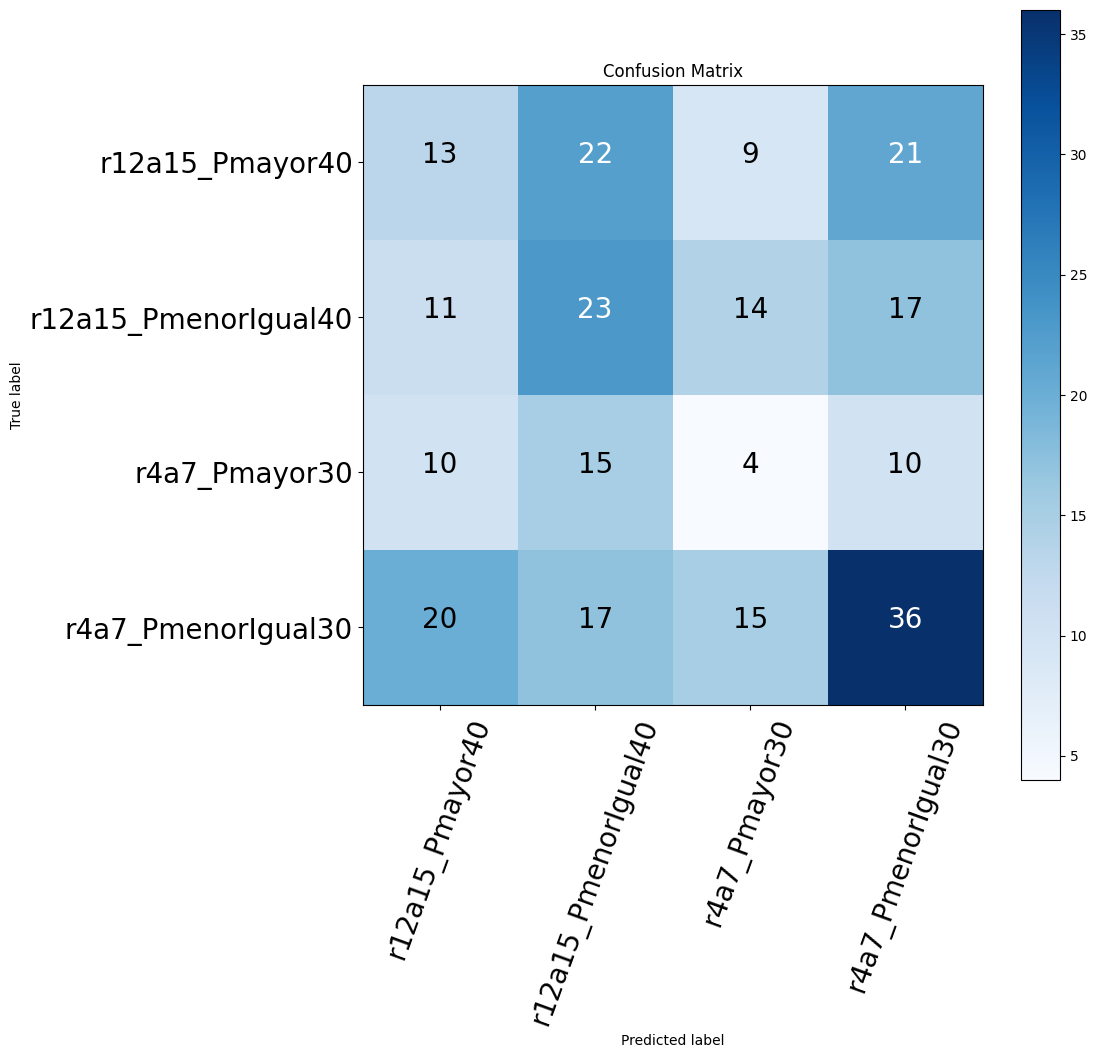

In [60]:
# Plot a confusion matrix with all 25250 predictions, ground truth labels and 101 classes
make_confusion_matrix(y_true=y_labels,
                      y_pred=pred_classes,
                      classes=class_names,
                      figsize=(10, 10),
                      text_size=20,
                      norm=False,
                      savefig=False)

In [61]:
from sklearn.metrics import classification_report
print(classification_report(y_labels, pred_classes))

              precision    recall  f1-score   support

           0       0.24      0.20      0.22        65
           1       0.30      0.35      0.32        65
           2       0.10      0.10      0.10        39
           3       0.43      0.41      0.42        88

    accuracy                           0.30       257
   macro avg       0.27      0.27      0.26       257
weighted avg       0.30      0.30      0.30       257



In [62]:
# Get a dictionary of the classification report
classification_report_dict = classification_report(y_labels, pred_classes, output_dict=True)
# Create empty dictionary
class_f1_scores = {}
# Loop through classification report items
for k, v in classification_report_dict.items():
  if k == "accuracy": # stop once we get to accuracy key
    break
  else:
    # Append class names and f1-scores to new dictionary
    class_f1_scores[class_names[int(k)]] = v["f1-score"]
class_f1_scores

{'r12a15_Pmayor40': 0.2184873949579832,
 'r12a15_PmenorIgual40': 0.323943661971831,
 'r4a7_Pmayor30': 0.09876543209876543,
 'r4a7_PmenorIgual30': 0.4186046511627907}

In [63]:
# Turn f1-scores into dataframe for visualization
import pandas as pd
f1_scores = pd.DataFrame({"class_name": list(class_f1_scores.keys()),
                          "f1-score": list(class_f1_scores.values())}).sort_values("f1-score", ascending=False)
f1_scores.head()

,class_name,f1-score
3,r4a7_PmenorIgual30,0.418605
1,r12a15_PmenorIgual40,0.323944
0,r12a15_Pmayor40,0.218487
2,r4a7_Pmayor30,0.098765


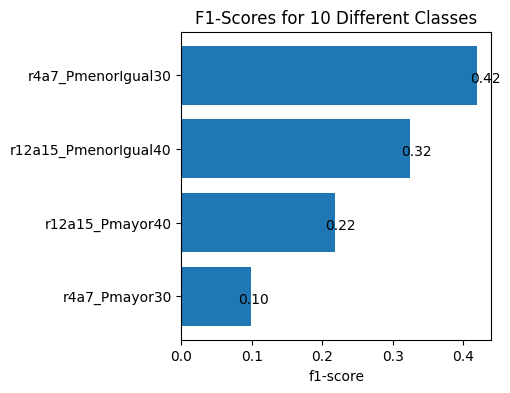

In [66]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4, 4))
scores = ax.barh(range(len(f1_scores)), f1_scores["f1-score"].values)
ax.set_yticks(range(len(f1_scores)))
ax.set_yticklabels(list(f1_scores["class_name"]))
ax.set_xlabel("f1-score")
ax.set_title("F1-Scores for 10 Different Classes")
ax.invert_yaxis(); # reverse the order

def autolabel(rects): # Modified version of: https://matplotlib.org/examples/api/barchart_demo.html
  """
  Attach a text label above each bar displaying its height (it's value).
  """
  for rect in rects:
    width = rect.get_width()
    ax.text(1.03*width, rect.get_y() + rect.get_height()/1.5,
            f"{width:.2f}",
            ha='center', va='bottom')

autolabel(scores)

In [91]:
def load_and_prep_image(filename, img_shape=256, scale=True):
  """
  Reads in an image from filename, turns it into a tensor and reshapes into
  (224, 224, 3).

  Parameters
  ----------
  filename (str): string filename of target image
  img_shape (int): size to resize target image to, default 224
  scale (bool): whether to scale pixel values to range(0, 1), default True
  """
  # Read in the image
  img = tf.io.read_file(filename)
  # Decode it into a tensor
  img = tf.io.decode_image(img)
  # Resize the image
  img = tf.image.resize(img, [img_shape, img_shape])
  if scale:
    # Rescale the image (get all values between 0 and 1)
    return img/255.
  else:
    return img

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


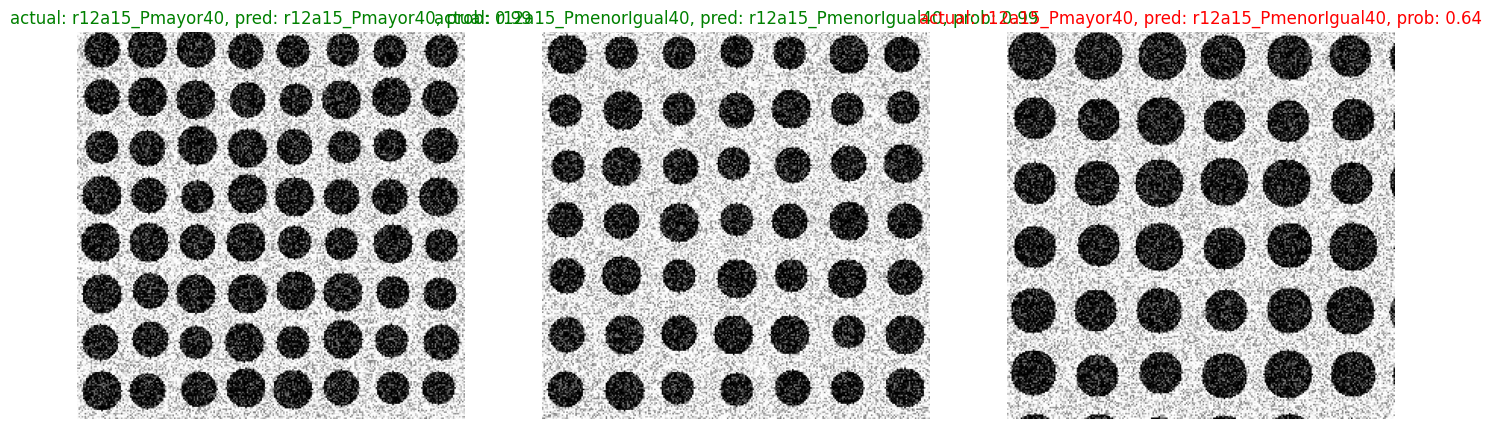

In [99]:
# Make preds on a series of random images
import os
import random

plt.figure(figsize=(17, 10))
for i in range(3):
    # Choose a random image from a random class 
    class_name = random.choice(class_names)
    filename = random.choice(os.listdir(test_dir + "/" + class_name))
    filepath = test_dir + class_name + "/" + filename
    
    # Load the image and make predictions
    img = load_and_prep_image(filepath, scale=False) # don't scale images for EfficientNet predictions

    # Convert into RGB image, just triplicating the original grayscale image:
    img = tf.image.grayscale_to_rgb(tf.expand_dims(tf.squeeze(img), axis=-1))

    pred_prob = model_2.predict(tf.expand_dims(img, axis=0)) # model accepts tensors of shape [None, 224, 224, 3]
    pred_class = class_names[pred_prob.argmax()] # find the predicted class 
    
    # Plot the image(s)
    plt.subplot(1, 3, i+1)
    plt.imshow(img/255.)
    if class_name == pred_class: # Change the color of text based on whether prediction is right or wrong
        title_color = "g"
    else:
        title_color = "r"
    plt.title(f"actual: {class_name}, pred: {pred_class}, prob: {pred_prob.max():.2f}", c=title_color)
    plt.axis(False);

In [102]:
# 1. Get the filenames of all of our test data
filepaths = []
for filepath in test_data.list_files("AAO_images/test/*/*.jpg", 
                                     shuffle=False):
    filepaths.append(filepath.numpy())
    
# 2. Create a dataframe out of current prediction data for analysis
pred_df = pd.DataFrame({"img_path": filepaths,
                        "y_true": y_labels,
                        "y_pred": pred_classes,
                        "pred_conf": pred_probs.max(axis=1), # get the maximum prediction probability value
                        "y_true_classname": [class_names[i] for i in y_labels],
                        "y_pred_classname": [class_names[i] for i in pred_classes]}) 
pred_df.head()

,img_path,y_true,y_pred,pred_conf,y_true_classname,y_pred_classname
0,b'AAO_images/test/r12a15_Pmayor40/Sim_AAO256x2...,0,3,0.919411,r12a15_Pmayor40,r4a7_PmenorIgual30
1,b'AAO_images/test/r12a15_Pmayor40/Sim_AAO256x2...,0,1,0.999446,r12a15_Pmayor40,r12a15_PmenorIgual40
2,b'AAO_images/test/r12a15_Pmayor40/Sim_AAO256x2...,0,1,0.621426,r12a15_Pmayor40,r12a15_PmenorIgual40
3,b'AAO_images/test/r12a15_Pmayor40/Sim_AAO256x2...,2,1,0.996423,r4a7_Pmayor30,r12a15_PmenorIgual40
4,b'AAO_images/test/r12a15_Pmayor40/Sim_AAO256x2...,3,1,0.998705,r4a7_PmenorIgual30,r12a15_PmenorIgual40


In [103]:
# 3. Is the prediction correct?
pred_df["pred_correct"] = pred_df["y_true"] == pred_df["y_pred"]
pred_df.head()

,img_path,y_true,y_pred,pred_conf,y_true_classname,y_pred_classname,pred_correct
0,b'AAO_images/test/r12a15_Pmayor40/Sim_AAO256x2...,0,3,0.919411,r12a15_Pmayor40,r4a7_PmenorIgual30,False
1,b'AAO_images/test/r12a15_Pmayor40/Sim_AAO256x2...,0,1,0.999446,r12a15_Pmayor40,r12a15_PmenorIgual40,False
2,b'AAO_images/test/r12a15_Pmayor40/Sim_AAO256x2...,0,1,0.621426,r12a15_Pmayor40,r12a15_PmenorIgual40,False
3,b'AAO_images/test/r12a15_Pmayor40/Sim_AAO256x2...,2,1,0.996423,r4a7_Pmayor30,r12a15_PmenorIgual40,False
4,b'AAO_images/test/r12a15_Pmayor40/Sim_AAO256x2...,3,1,0.998705,r4a7_PmenorIgual30,r12a15_PmenorIgual40,False


In [104]:
# 4. Get the top 30 wrong examples
top_100_wrong = pred_df[pred_df["pred_correct"] == False].sort_values("pred_conf", ascending=False)[:30]
top_100_wrong.head(10)

,img_path,y_true,y_pred,pred_conf,y_true_classname,y_pred_classname,pred_correct
51,b'AAO_images/test/r12a15_Pmayor40/Sim_AAO256x2...,0,1,0.999982,r12a15_Pmayor40,r12a15_PmenorIgual40,False
254,b'AAO_images/test/r4a7_PmenorIgual30/Sim_AAO25...,0,1,0.999971,r12a15_Pmayor40,r12a15_PmenorIgual40,False
193,b'AAO_images/test/r4a7_PmenorIgual30/Sim_AAO25...,0,1,0.999959,r12a15_Pmayor40,r12a15_PmenorIgual40,False
128,b'AAO_images/test/r12a15_PmenorIgual40/Sim_AAO...,2,1,0.999939,r4a7_Pmayor30,r12a15_PmenorIgual40,False
104,b'AAO_images/test/r12a15_PmenorIgual40/Sim_AAO...,3,1,0.999928,r4a7_PmenorIgual30,r12a15_PmenorIgual40,False
105,b'AAO_images/test/r12a15_PmenorIgual40/Sim_AAO...,2,1,0.999907,r4a7_Pmayor30,r12a15_PmenorIgual40,False
140,b'AAO_images/test/r4a7_Pmayor30/Sim_AAO256x256...,3,1,0.999905,r4a7_PmenorIgual30,r12a15_PmenorIgual40,False
224,b'AAO_images/test/r4a7_PmenorIgual30/Sim_AAO25...,3,1,0.999896,r4a7_PmenorIgual30,r12a15_PmenorIgual40,False
174,b'AAO_images/test/r4a7_PmenorIgual30/Sim_AAO25...,0,1,0.999828,r12a15_Pmayor40,r12a15_PmenorIgual40,False
172,b'AAO_images/test/r4a7_PmenorIgual30/Sim_AAO25...,0,1,0.999787,r12a15_Pmayor40,r12a15_PmenorIgual40,False


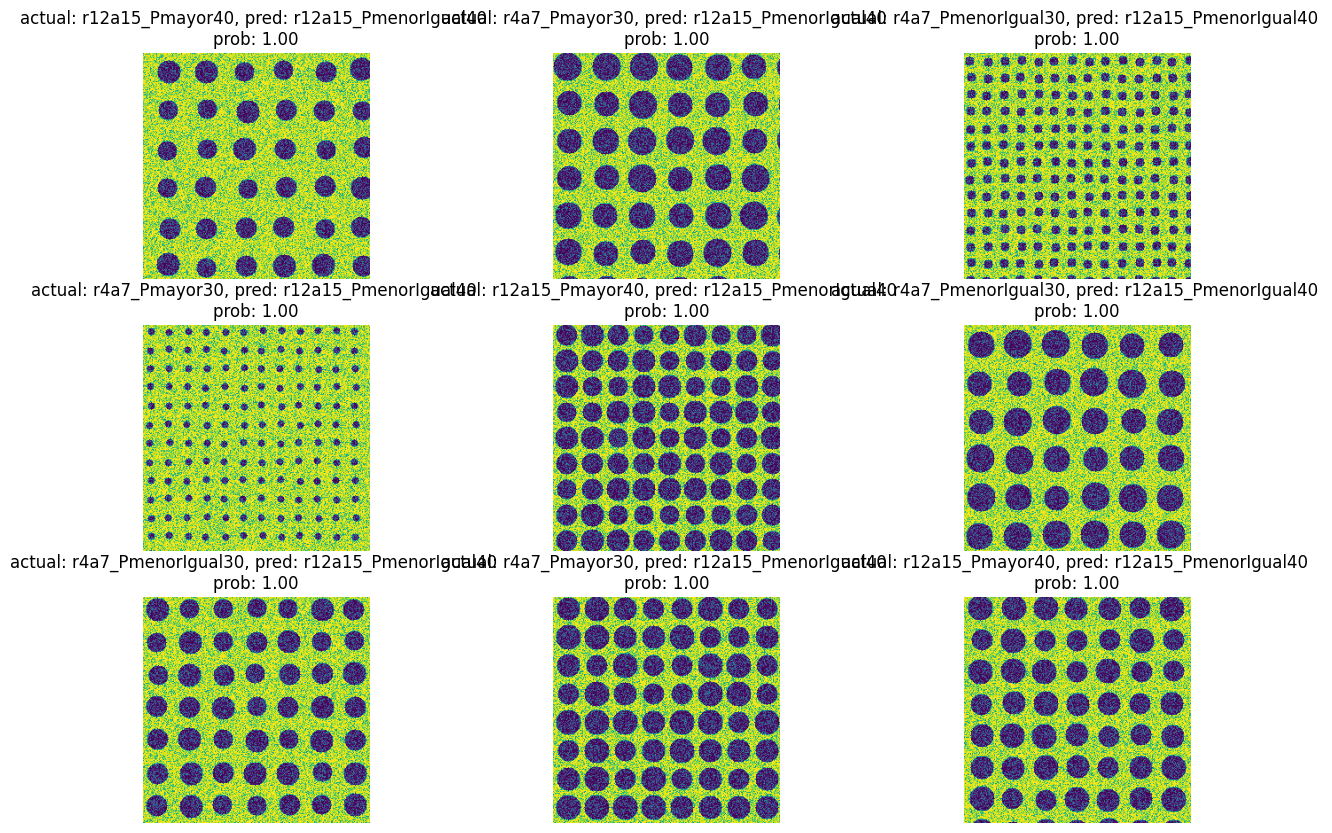

In [105]:
# 5. Visualize some of the most wrong examples
images_to_view = 9
start_index = 10 # change the start index to view more
plt.figure(figsize=(15, 10))
for i, row in enumerate(top_100_wrong[start_index:start_index+images_to_view].itertuples()): 
  plt.subplot(3, 3, i+1)
  img = load_and_prep_image(row[1], scale=True)
  _, _, _, _, pred_prob, y_true, y_pred, _ = row # only interested in a few parameters of each row
  plt.imshow(img)
  plt.title(f"actual: {y_true}, pred: {y_pred} \nprob: {pred_prob:.2f}")
  plt.axis(False)

In [ ]:
# Tip to print multi-lines text:
# Output info about our training sample
for image, label in train_one_sample:
  print(f"""
  Image shape: {image.shape}
  Image dtype: {image.dtype}
  Target class from Food101 (tensor form): {label}
  Class name (str form): {class_names[label.numpy()]}
        """)

## More tips (variable names are from a different notebook)

Useful info:

https://www.tensorflow.org/guide/data_performance#best_practice_summary

### Resize image and convert data type uint8 into float

In [ ]:
# Make a function for preprocessing images
def preprocess_img(image, label, img_shape=224):
    """
    Converts image datatype from 'uint8' -> 'float32' and reshapes image to
    [img_shape, img_shape, color_channels]
    """
    image = tf.image.resize(image, [img_shape, img_shape]) # reshape to img_shape
    return tf.cast(image, tf.float32), label # return (float32_image, label) tuple

### Batch data

In [ ]:
# Map preprocessing function to training data (and paralellize)
train_data = train_data.map(map_func=preprocess_img, num_parallel_calls=tf.data.AUTOTUNE)
# Shuffle train_data and turn it into batches and prefetch it (load it faster)
train_data = train_data.shuffle(buffer_size=1000).batch(batch_size=32).prefetch(buffer_size=tf.data.AUTOTUNE)

# Map prepreprocessing function to test data
test_data = test_data.map(preprocess_img, num_parallel_calls=tf.data.AUTOTUNE)
# Turn test data into batches (don't need to shuffle)
test_data = test_data.batch(32).prefetch(tf.data.AUTOTUNE)

### Set up Mixed Precision

Source: https://www.tensorflow.org/guide/mixed_precision#supported_hardware

In [3]:
# Turn on mixed precision training
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy(policy="mixed_float16") # set global policy to mixed precision 

In [2]:
mixed_precision.global_policy() # should output "mixed_float16" (if your GPU is compatible with mixed precision)

<DTypePolicy "mixed_float16">

In [6]:
import tensorflow as tf
from tensorflow.keras import layers

class_names = ['A','B','C']

# Create base model
input_shape = (224, 224, 3)
base_model = tf.keras.applications.EfficientNetB0(include_top=False)
base_model.trainable = False # freeze base model layers

# Create Functional model 
inputs = layers.Input(shape=input_shape, name="input_layer")
# Note: EfficientNetBX models have rescaling built-in but if your model didn't you could have a layer like below
# x = layers.Rescaling(1./255)(x)
x = base_model(inputs, training=False) # set base_model to inference mode only
x = layers.GlobalAveragePooling2D(name="pooling_layer")(x)
x = layers.Dense(len(class_names))(x) # want one output neuron per class 
# Separate activation of output layer so we can output float32 activations
outputs = layers.Activation("softmax", dtype=tf.float32, name="softmax_float32")(x) 
model = tf.keras.Model(inputs, outputs)

# Compile the model
model.compile(loss="sparse_categorical_crossentropy", # Use sparse_categorical_crossentropy when labels are *not* one-hot
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

In [7]:
# Check out our model
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_float32 (Activation)    │ (None, 3)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [8]:
# Check the dtype_policy attributes of layers in our model
for layer in model.layers:
    print(layer.name, layer.trainable, layer.dtype, layer.dtype_policy) # Check the dtype policy of layers

input_layer True float32 <DTypePolicy "mixed_float16">
efficientnetb0 False float32 <DTypePolicy "mixed_float16">
pooling_layer True float32 <DTypePolicy "mixed_float16">
dense True float32 <DTypePolicy "mixed_float16">
softmax_float32 True float32 <DTypePolicy "float32">


In [11]:
# Check the layers in the base model and see what dtype policy they're using
for layer in model.layers[1].layers[-10:]: # only check the first 20 layers to save output space
    print(layer.name, layer.trainable, layer.dtype, layer.dtype_policy)

block7a_se_squeeze False float32 <DTypePolicy "mixed_float16">
block7a_se_reshape False float32 <DTypePolicy "mixed_float16">
block7a_se_reduce False float32 <DTypePolicy "mixed_float16">
block7a_se_expand False float32 <DTypePolicy "mixed_float16">
block7a_se_excite False float32 <DTypePolicy "mixed_float16">
block7a_project_conv False float32 <DTypePolicy "mixed_float16">
block7a_project_bn False float32 <DTypePolicy "mixed_float16">
top_conv False float32 <DTypePolicy "mixed_float16">
top_bn False float32 <DTypePolicy "mixed_float16">
top_activation False float32 <DTypePolicy "mixed_float16">
